# 🛡️ Cybersecurity Intrusion Detection System
## Pure Step-by-Step Machine Learning Workflow (No Pipeline Wrapper)

This notebook implements the complete machine learning workflow explicitly cell-by-cell without using `Pipeline` or `ColumnTransformer` wrappers:
1. **Zero Data Leakage:** Train/Test split is performed *first*. Scaler (`StandardScaler`), imputers, and encoders are fitted **strictly on `X_train`** and applied to `X_test`.
2. **Explicit Data Alignment:** Proper index preservation during pandas concatenation.
3. **Outlier Exploration:** Multi-panel boxplots and domain attack correlations.
4. **Model Training & Evaluation:** `RandomForestClassifier` with classification metrics and decision threshold calibration.
5. **Interpretability & Live Scoring:** SHAP waterfall analysis and manual inference on incoming traffic events.
6. **Production Serialization:** Exporting model + scaler + imputers + encoder dictionary as a `.joblib` bundle for backend deployment.


### Step 1: Library Imports


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    precision_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)
import shap
import joblib

# Visualization theme
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
sns.set_palette('crest')


C:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Step 2: Ingest & Inspect Dataset


In [2]:
df = pd.read_csv('cybersecurity_intrusion_data.csv')

print(f"Dataset Dimensions: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()


Dataset Dimensions: 9537 rows, 11 columns


,session_id,network_packet_size,protocol_type,login_attempts,session_duration,encryption_used,ip_reputation_score,failed_logins,browser_type,unusual_time_access,attack_detected
0,SID_00001,599,TCP,4,492.983263,DES,0.606818,1,Edge,0,1
1,SID_00002,472,TCP,3,1557.996461,DES,0.301569,0,Firefox,0,0
2,SID_00003,629,TCP,3,75.044262,DES,0.739164,2,Chrome,0,1
3,SID_00004,804,UDP,4,601.248835,DES,0.123267,0,Unknown,0,1
4,SID_00005,453,TCP,5,532.540888,AES,0.054874,1,Firefox,0,0


### Step 3: Dataset Summary & Class Balance


In [3]:
print("--- Missing Values Count ---")
print(df.isnull().sum())

print("\n--- Target Class Balance (0 = Normal, 1 = Attack) ---")
print(df['attack_detected'].value_counts(normalize=True).rename('proportion').to_frame())


--- Missing Values Count ---
session_id                0
network_packet_size       0
protocol_type             0
login_attempts            0
session_duration          0
encryption_used        1966
ip_reputation_score       0
failed_logins             0
browser_type              0
unusual_time_access       0
attack_detected           0
dtype: int64

--- Target Class Balance (0 = Normal, 1 = Attack) ---
                 proportion
attack_detected            
0                  0.552899
1                  0.447101


### Step 4: Corrected IQR Outlier Analysis & Feature Distributions
*Using bitwise OR (`|`) to identify points below the lower bound OR above the upper bound.*


,Feature,Lower Bound,Upper Bound,Outlier Count,Outlier %,Attack % in Outliers,Min,Max
0,network_packet_size,-40.00,1040.00,37,0.39,43.2%,64.0,1285.00
1,login_attempts,0.00,8.00,206,2.16,100.0%,1.0,13.00
2,session_duration,-1078.19,2415.52,418,4.38,54.3%,0.5,7190.39
3,ip_reputation_score,-0.20,0.85,21,0.22,100.0%,0.0,0.92
4,failed_logins,-0.50,3.50,323,3.39,100.0%,0.0,5.00
5,unusual_time_access,0.00,0.00,1430,14.99,45.7%,0.0,1.00


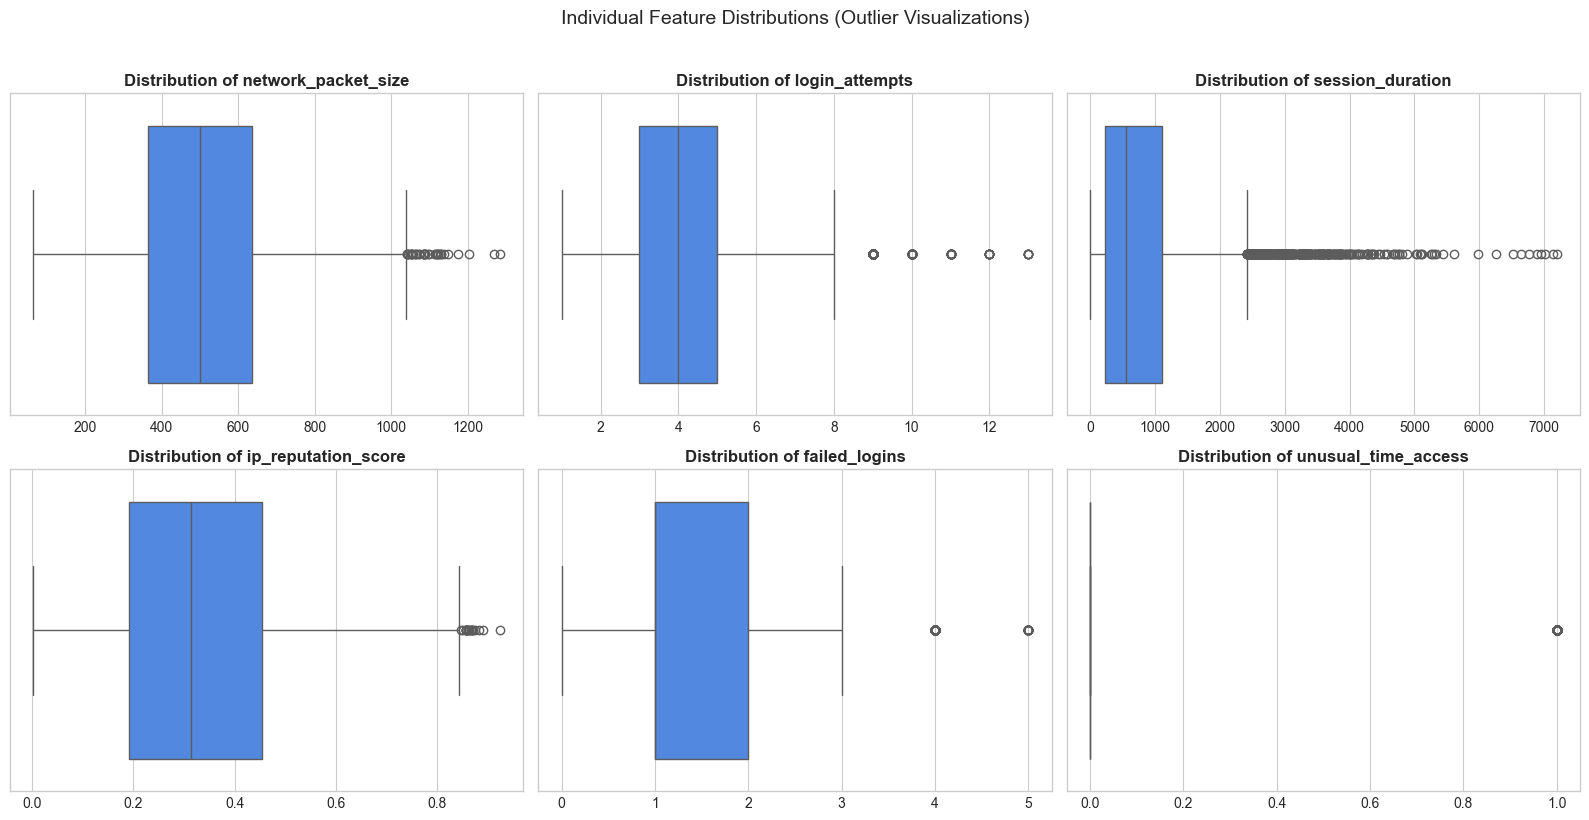

In [4]:
numeric_cols = [
    'network_packet_size', 'login_attempts', 'session_duration', 
    'ip_reputation_score', 'failed_logins', 'unusual_time_access'
]

outlier_records = []
for col in numeric_cols:
    q25, q75 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr = q75 - q25
    lower_bound = q25 - 1.5 * iqr
    upper_bound = q75 + 1.5 * iqr
    
    outlier_mask = (df[col] < lower_bound) | (df[col] > upper_bound)
    outlier_subset = df[outlier_mask]
    attack_rate_in_outliers = (outlier_subset['attack_detected'].mean() * 100) if len(outlier_subset) > 0 else 0
    
    outlier_records.append({
        'Feature': col,
        'Lower Bound': round(lower_bound, 2),
        'Upper Bound': round(upper_bound, 2),
        'Outlier Count': int(outlier_mask.sum()),
        'Outlier %': round((outlier_mask.sum() / len(df)) * 100, 2),
        'Attack % in Outliers': f"{attack_rate_in_outliers:.1f}%",
        'Min': round(df[col].min(), 2),
        'Max': round(df[col].max(), 2)
    })

outlier_df = pd.DataFrame(outlier_records)
display(outlier_df)

# Individual Subplots
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(x=df[col], ax=axes[i], color='#3b82f6')
    axes[i].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')

plt.suptitle('Individual Feature Distributions (Outlier Visualizations)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


### Step 5: Feature-Target Separation & Train-Test Split
*Splitting before fitting any preprocessing tools ensures Zero Data Leakage.*


In [5]:
# Separate Features (X) and Target (y)
X = df.drop(columns=['session_id', 'attack_detected'])
y = df['attack_detected']

# Stratified Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"X_train Shape: {X_train.shape}")
print(f"X_test Shape : {X_test.shape}")


X_train Shape: (7629, 9)
X_test Shape : (1908, 9)


### Step 6: Step-by-Step Feature Preprocessing (StandardScaler & OneHotEncoder)
1. **Numeric**: Median Imputation $\rightarrow$ `StandardScaler` (fit on `X_train`, transform `X_train` and `X_test`).
2. **Categorical**: Impute with `'Unknown'` $\rightarrow$ `OneHotEncoder` (fit on `X_train`, transform `X_train` and `X_test`).
3. **Merge**: Combine numeric and categorical DataFrames using matching index to avoid NaNs.


In [6]:
numeric_cols = [
    'network_packet_size', 'login_attempts', 'session_duration', 
    'ip_reputation_score', 'failed_logins', 'unusual_time_access'
]
categorical_cols = ['protocol_type', 'encryption_used', 'browser_type']

# --- A. NUMERICAL PREPROCESSING (StandardScaler) ---
num_imputer = SimpleImputer(strategy='median')
scaler = StandardScaler()

# Fit ONLY on X_train, then transform both
X_train_num_imp = num_imputer.fit_transform(X_train[numeric_cols])
X_train_num_scaled = scaler.fit_transform(X_train_num_imp)

X_test_num_imp = num_imputer.transform(X_test[numeric_cols])
X_test_num_scaled = scaler.transform(X_test_num_imp)

# Build DataFrames with preserved indices
df_train_num = pd.DataFrame(X_train_num_scaled, columns=numeric_cols, index=X_train.index)
df_test_num = pd.DataFrame(X_test_num_scaled, columns=numeric_cols, index=X_test.index)


# --- B. CATEGORICAL PREPROCESSING (OneHotEncoder) ---
cat_imputer = SimpleImputer(strategy='constant', fill_value='Unknown')
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Fit ONLY on X_train, then transform both
X_train_cat_imp = cat_imputer.fit_transform(X_train[categorical_cols])
X_train_cat_encoded = encoder.fit_transform(X_train_cat_imp)

X_test_cat_imp = cat_imputer.transform(X_test[categorical_cols])
X_test_cat_encoded = encoder.transform(X_test_cat_imp)

encoded_cat_cols = encoder.get_feature_names_out(categorical_cols)

# Build DataFrames with preserved indices
df_train_cat = pd.DataFrame(X_train_cat_encoded, columns=encoded_cat_cols, index=X_train.index)
df_test_cat = pd.DataFrame(X_test_cat_encoded, columns=encoded_cat_cols, index=X_test.index)


# --- C. CONCATENATE PROCESSED MATRICES ---
X_train_processed = pd.concat([df_train_num, df_train_cat], axis=1)
X_test_processed = pd.concat([df_test_num, df_test_cat], axis=1)

print("Processed Training Features Shape:", X_train_processed.shape)
print("Processed Testing Features Shape :", X_test_processed.shape)
display(X_train_processed.head(3))


Processed Training Features Shape: (7629, 17)
Processed Testing Features Shape : (1908, 17)


,network_packet_size,login_attempts,session_duration,ip_reputation_score,failed_logins,unusual_time_access,protocol_type_ICMP,protocol_type_TCP,protocol_type_UDP,encryption_used_AES,encryption_used_DES,encryption_used_Unknown,browser_type_Chrome,browser_type_Edge,browser_type_Firefox,browser_type_Safari,browser_type_Unknown
3334,1.400674,0.989654,-0.758065,0.961348,0.460961,-0.420872,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4684,-1.055944,0.484903,1.314633,-0.344061,0.460961,-0.420872,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
6385,1.269520,-1.029351,0.292449,-0.695732,0.460961,-0.420872,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


### Step 7: Model Training (Random Forest Classifier)


In [7]:
model = RandomForestClassifier(
    n_estimators=300,
    min_samples_split=5,
    min_samples_leaf=1,
    class_weight='balanced_subsample',
    random_state=42,
    n_jobs=-1
)

# Train on processed features
model.fit(X_train_processed, y_train)
print("✅ Model trained successfully!")


✅ Model trained successfully!


### Step 8: Model Evaluation & Calibrated Security Threshold


In [8]:
# Predict probabilities on test set
y_test_proba = model.predict_proba(X_test_processed)[:, 1]

# Calibrated Security Decision Threshold (0.35 gives higher recall for attacks)
decision_threshold = 0.35
y_test_pred = (y_test_proba >= decision_threshold).astype(int)

roc_auc = roc_auc_score(y_test, y_test_proba)

print("=" * 50)
print(f"  ROC-AUC SCORE: {roc_auc:.4f}")
print("=" * 50)

print(f"\n--- Performance at Threshold ({decision_threshold}) ---")
print(f"Accuracy Score : {accuracy_score(y_test, y_test_pred):.4f}")
print(f"Precision Score: {precision_score(y_test, y_test_pred):.4f}")
print(f"Recall Score   : {recall_score(y_test, y_test_pred):.4f}")
print(f"F1 Score       : {f1_score(y_test, y_test_pred):.4f}")

print("\n--- Confusion Matrix ---")
print(confusion_matrix(y_test, y_test_pred))

print("\n--- Detailed Classification Report ---")
print(classification_report(y_test, y_test_pred, target_names=['Normal (0)', 'Attack (1)']))


  ROC-AUC SCORE: 0.8777

--- Performance at Threshold (0.35) ---
Accuracy Score : 0.8726
Precision Score: 0.9382
Recall Score   : 0.7655


F1 Score       : 0.8431

--- Confusion Matrix ---
[[1012   43]
 [ 200  653]]

--- Detailed Classification Report ---
              precision    recall  f1-score   support

  Normal (0)       0.83      0.96      0.89      1055
  Attack (1)       0.94      0.77      0.84       853

    accuracy                           0.87      1908
   macro avg       0.89      0.86      0.87      1908
weighted avg       0.88      0.87      0.87      1908



### Step 9: ROC and Precision-Recall Visualizations


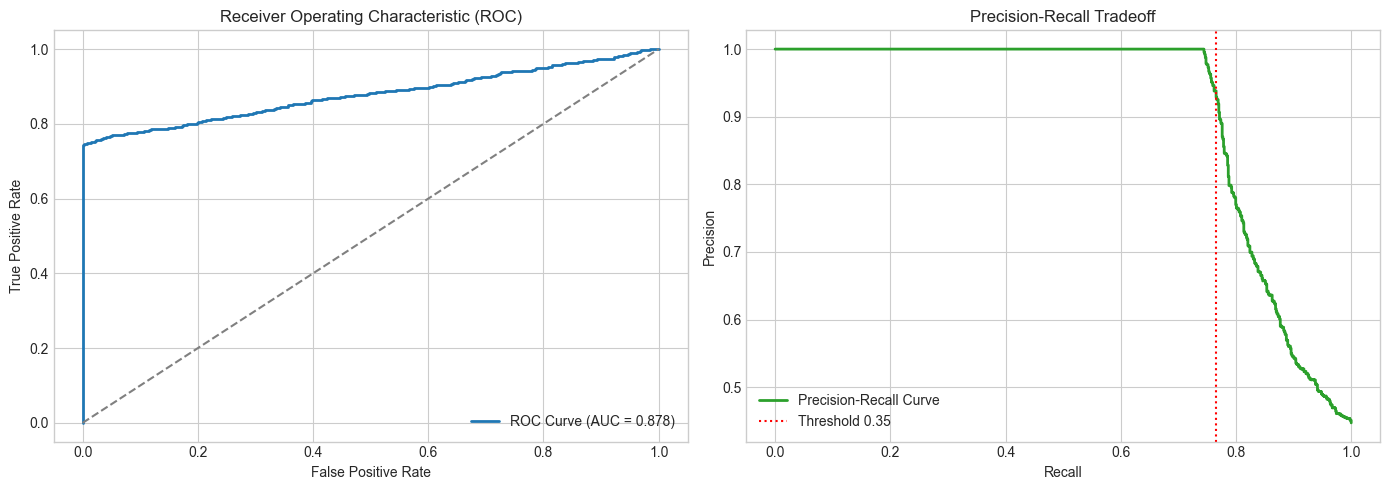

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_test_proba)
axes[0].plot(fpr, tpr, color='#1f77b4', lw=2, label=f'ROC Curve (AUC = {roc_auc:.3f})')
axes[0].plot([0, 1], [0, 1], color='gray', linestyle='--')
axes[0].set_title('Receiver Operating Characteristic (ROC)', fontsize=12)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(loc='lower right')

# Precision-Recall Curve
precisions, recalls, _ = precision_recall_curve(y_test, y_test_proba)
axes[1].plot(recalls, precisions, color='#2ca02c', lw=2, label='Precision-Recall Curve')
axes[1].axvline(x=recall_score(y_test, y_test_pred), color='red', linestyle=':', label=f'Threshold {decision_threshold}')
axes[1].set_title('Precision-Recall Tradeoff', fontsize=12)
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend(loc='lower left')

plt.tight_layout()
plt.show()


### Step 10: Model Explainability via SHAP


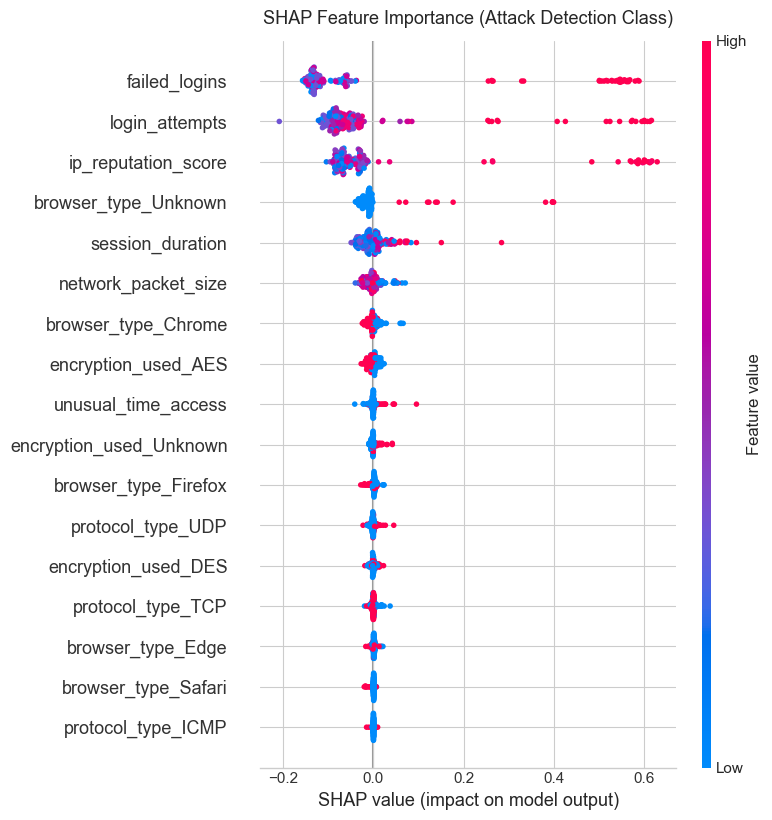

In [10]:
# Initialize SHAP TreeExplainer
explainer = shap.TreeExplainer(model)

# Compute SHAP values for test samples
shap_values = explainer(X_test_processed.iloc[:200])

# Global Feature Importance Summary Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values[..., 1], X_test_processed.iloc[:200], show=False)
plt.title('SHAP Feature Importance (Attack Detection Class)', fontsize=13, pad=12)
plt.tight_layout()
plt.show()


### Step 11: Live Event Inference (Explicit Step-by-Step Transformation)
*Transforming an incoming raw network log using the fitted transformers without re-fitting.*


         LIVE SECURITY DIAGNOSTIC
Raw Threat Probability : 96.85%
Decision Threshold     : 35%
Action Taken           : 🚨 BLOCKED - INTRUSION DETECTED


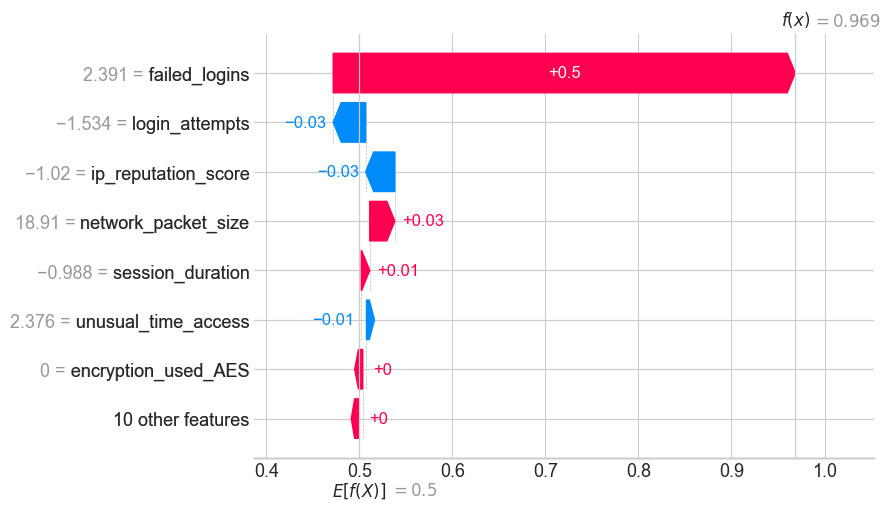

In [11]:
# 1. Define incoming raw evaluation sample
new_log = pd.DataFrame([{
    'network_packet_size': 4250,
    'login_attempts': 1,
    'session_duration': 12.0,
    'ip_reputation_score': 0.15,
    'failed_logins': 4,
    'unusual_time_access': 1,
    'protocol_type': 'TCP',
    'encryption_used': 'DES',
    'browser_type': 'Chrome'
}])

# 2. Transform numerical values using fitted num_imputer and scaler
new_num_imp = num_imputer.transform(new_log[numeric_cols])
new_num_scaled = scaler.transform(new_num_imp)
df_new_num = pd.DataFrame(new_num_scaled, columns=numeric_cols, index=new_log.index)

# 3. Transform categorical values using fitted cat_imputer and encoder
new_cat_imp = cat_imputer.transform(new_log[categorical_cols])
new_cat_encoded = encoder.transform(new_cat_imp)
df_new_cat = pd.DataFrame(new_cat_encoded, columns=encoded_cat_cols, index=new_log.index)

# 4. Concatenate transformed features
X_sample_live = pd.concat([df_new_num, df_new_cat], axis=1)

# 5. Predict threat probability
threat_prob = model.predict_proba(X_sample_live)[0, 1]
is_attack = int(threat_prob >= decision_threshold)

print("=" * 45)
print("         LIVE SECURITY DIAGNOSTIC")
print("=" * 45)
print(f"Raw Threat Probability : {threat_prob * 100:.2f}%")
print(f"Decision Threshold     : {decision_threshold * 100:.0f}%")
status_text = "🚨 BLOCKED - INTRUSION DETECTED" if is_attack else "🟩 ALLOWED - NORMAL TRAFFIC"
print(f"Action Taken           : {status_text}")

# 6. Local Waterfall Plot for this live sample
sample_shap = explainer(X_sample_live)
plt.figure(figsize=(8, 4))
shap.plots.waterfall(sample_shap[0, ..., 1], max_display=8)


### Step 12: Save Complete Model Bundle (.joblib) for Deployment
*Bundles the trained model, scaler, imputers, encoder, and column configurations into a single dictionary artifact for seamless production/web deployment.*


In [12]:
# 1. Package all preprocessing artifacts and model into a single dictionary bundle
model_bundle = {
    'model': model,
    'scaler': scaler,
    'num_imputer': num_imputer,
    'cat_imputer': cat_imputer,
    'encoder': encoder,
    'numeric_cols': numeric_cols,
    'categorical_cols': categorical_cols,
    'encoded_cat_cols': list(encoded_cat_cols),
    'decision_threshold': decision_threshold
}

# 2. Save bundle to disk
bundle_filename = 'intrusion_model_bundle.joblib'
joblib.dump(model_bundle, bundle_filename)
print(f"🎉 Complete Model Bundle successfully saved to: {bundle_filename}")

# 3. Verification: Load bundle and test live prediction
loaded_bundle = joblib.load(bundle_filename)

# Test loaded bundle with new_log
test_num = loaded_bundle['scaler'].transform(loaded_bundle['num_imputer'].transform(new_log[loaded_bundle['numeric_cols']]))
test_cat = loaded_bundle['encoder'].transform(loaded_bundle['cat_imputer'].transform(new_log[loaded_bundle['categorical_cols']]))
test_features = np.hstack([test_num, test_cat])

predicted_prob = loaded_bundle['model'].predict_proba(test_features)[0, 1]
predicted_action = "🚨 ATTACK" if predicted_prob >= loaded_bundle['decision_threshold'] else "🟩 NORMAL"

print(f"Verification Test Probability: {predicted_prob * 100:.2f}% -> Outcome: {predicted_action}")


🎉 Complete Model Bundle successfully saved to: intrusion_model_bundle.joblib


C:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


Verification Test Probability: 96.85% -> Outcome: 🚨 ATTACK
